# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science**
### *Pipeline de datos: Capa Gold*
---

**Input:** `data/02_silver/dataset_analitico.csv` - 2.947 asalariados, 64 variables limpias  
**Output:** `data/03_gold/dataset_modelado.csv` - dataset listo para modelado (features + target)

---

### *Estructura del notebook*

| Sección | Contenido |
|---------|-----------|
| G.0 | Setup y carga del dataset Silver |
| G.1 | Construcción del target `estres_financiero_alto` |
| G.2 | Train / Test Split |
| G.3 | Eliminación de variables no útiles para el modelo |
| G.4 | Feature engineering |
| G.5 | Imputación semántica (no estadística) |
| G.6 | Encoding con mapa fijo |
| G.7 | Definición del ColumnTransformer y Pipeline base |
| G.8 | Verificación de integridad del Pipeline |
| G.9 | Inventario de nulos pendientes para el Pipeline |
| G.10 | Resumen del dataset Gold y exportación |
| G.11 | Decisiones de diseño — resumen |

> **Nota:** Este notebook documenta y justifica cada decisión con exploración visual.
> El código de producción ejecutable está en `gold_ecv.py`.

---


## G.0 **Configuración del entorno**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn import set_config

from utils.constants_var import PATH_SILVER_ANALITICO, COLS_AUX, COLS_LOG1P, COLS_BINARIAS
from utils.mapeo_utils import COMPONENTES_ESTRES, MAPA_ESTUDIOS, ENCODING_ORDINAL, MAPA_BINARIO
from utils.visualizations_utils import distribucion_target, dis_components_target, ratio_carga_vivienda, distribucion_logs

df = pd.read_csv(PATH_SILVER_ANALITICO, low_memory=False)
print(f'Dataset Silver cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')


Dataset Silver cargado: 2,947 filas × 64 columnas


## G.1 **Train / Test Split - PRIMERA OPERACIÓN**

El split se realiza **sobre el dataset Silver**, antes de cualquier transformación
que aprenda parámetros de los datos (imputación estadística, OHE, escalado).
Aplicarlo después introduciría *data leakage*: los parámetros del preprocesado
(mediana, moda, categorías del encoder) quedarían contaminados con información del test.

**Parámetros:**
- `test_size = 0.20` → 80% train / 20% test  
- `random_state = 42` → reproducibilidad  
- `stratify = y` → mantiene la proporción 84/16% en ambos conjuntos

> **Arquitectura de responsabilidades:**
> ```
> gold_ecv.py (determinista)          Notebook modelado (aprende de datos)
> ────────────────────────            ────────────────────────────────────
> Todas las transformaciones  →  PASO 1: train_test_split  ← AQUÍ
> de G.2 a G.6 son seguras         PASO 2: Pipeline.fit(X_train)
> antes del split                  PASO 3: evaluar sobre X_test
> ```


In [2]:
# Construir target preliminar para poder hacer el split estratificado
# (la construcción completa con visualizaciones está en G.2)

for col, vals in COMPONENTES_ESTRES.items():
    df[f'_comp_{col}'] = df[col].isin(vals).astype('Int64')

comp_cols = [f'_comp_{c}' for c in COMPONENTES_ESTRES]
score_comp = df[comp_cols].sum(axis=1, skipna=True)
not_nulls = df[comp_cols].notna().sum(axis=1)

df['estres_financiero_alto'] = np.where(
    score_comp >= 2, 1,
    np.where((score_comp < 2) & (not_nulls >= 4), 0, np.nan)
).astype(int)

df = df.drop(columns=comp_cols)

In [3]:
# Verificación de nulos ya que son indeterminables, no se modelan
df['estres_financiero_alto'].isna().sum()

np.int64(0)

In [3]:
# Split estratificado
X = df.drop(columns=[c for c in COLS_AUX if c in df.columns])
y = df['estres_financiero_alto'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('─' * 50)
print(f'Total observaciones:  {len(X):,}')
print(f'Train:                {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test:                 {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print('─' * 50)
print(f'Distribución del target:')
print(f'  Train — clase 0: {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)'
      f'  |  clase 1: {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)')
print(f'  Test  — clase 0: {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)'
      f'  |  clase 1: {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)')


──────────────────────────────────────────────────
Total observaciones:  2,947
Train:                2,357  (80.0%)
Test:                 590  (20.0%)
──────────────────────────────────────────────────
Distribución del target:
  Train — clase 0: 1,985  (84.2%)  |  clase 1: 372  (15.8%)
  Test  — clase 0: 497  (84.2%)  |  clase 1: 93  (15.8%)


In [4]:
train_set = X_train
train_set['estres_financiero_alto'] = y_train

In [5]:
test_set = X_test
test_set['estres_financiero_alto'] = y_test

> En `gold_ecv.py` se guardan los dos sets de entrenamiento y testeo en CSVs

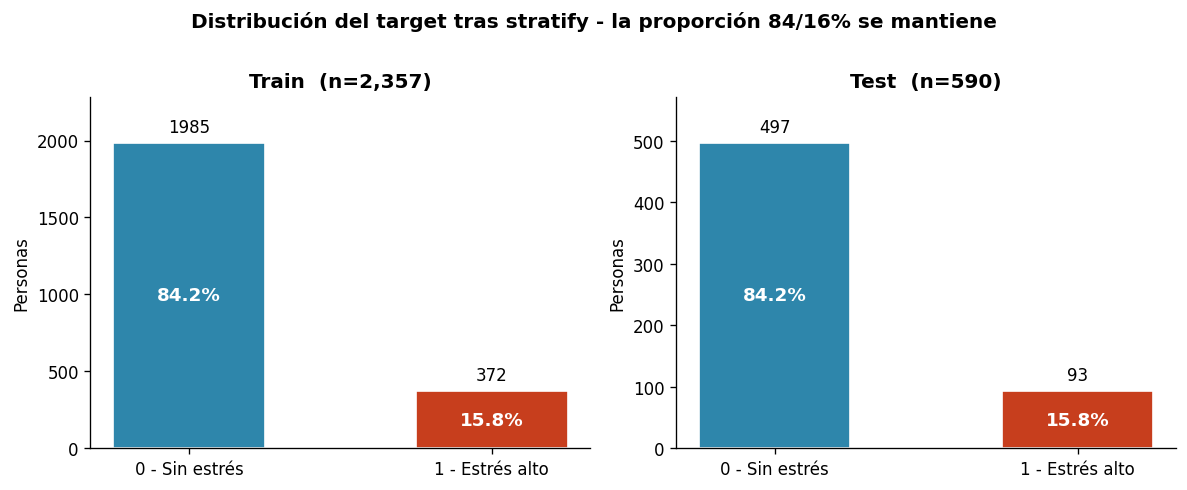

Ratio clase 1 - Train: 0.1578  |  Test: 0.1576
Diferencia absoluta:   0.0002  (debe ser < 0.005)


In [7]:
# Visualización: distribución del target en train y test
distribucion_target(y_train, y_test)

## G.2 **Construcción del target `estres_financiero_alto`**

El target es una **variable binaria** construida a partir de 5 componentes de la ECV.
Ya fue computado en G.1 para el split estratificado. Aquí se documenta y visualiza.

**Regla:** ≥ 2 de 5 condiciones activas = estrés financiero alto.

| Componente | Variable | Condición de estrés |
|------------|----------|---------------------|
| Dificultad fin de mes | `capacidad_fin_de_mes` | `Con mucha dificultad` o `Con dificultad` |
| Sin colchón para imprevistos | `capacidad_gastos_imprevistos` | `No (no puede)` |
| Retrasos en facturas | `retrasos_facturas` | `Sí, una vez` o `Sí, dos o más veces` |
| Retrasos hipoteca/alquiler | `retrasos_hipoteca_alquiler` | `Sí, una vez` o `Sí, dos o más veces` |
| Retrasos en deudas | `retrasos_deudas_no_vivienda` | `Sí, una vez` o `Sí, dos o más veces` |

**¿Por qué ≥ 2 condiciones?** Un único indicador puede reflejar una situación puntual.
Exigir al menos dos condiciones simultáneas garantiza un perfil **persistente y multidimensional**,
coherente con la literatura sobre vulnerabilidad financiera de hogares.


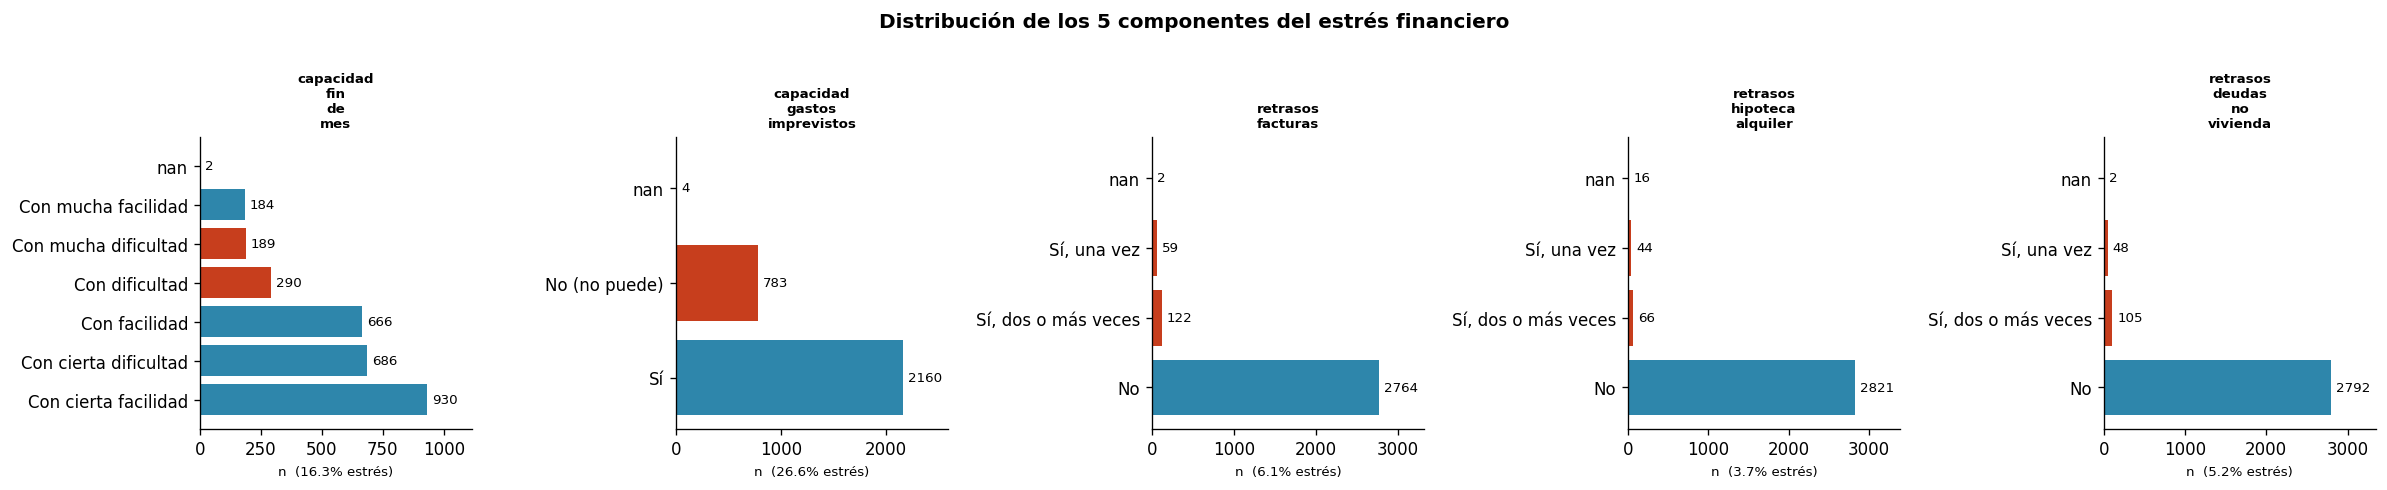

Rojo = condición activa | Azul = sin estrés | Gris = NaN


In [6]:
# Distribución individual de los 5 componentes (sobre el total Silver)
dis_components_target(df, COMPONENTES_ESTRES)

In [6]:
# Distribución del target en el conjunto completo
vc = train_set['estres_financiero_alto'].value_counts(dropna=False)
n0, n1 = vc.get(0, 0), vc.get(1, 0)
n_nan = df['estres_financiero_alto'].isna().sum()

print('TARGET: estres_financiero_alto')
print(f'  0 - sin estrés alto:  {n0:,}  ({n0/len(train_set)*100:.1f}%)')
print(f'  1 - estrés alto:      {n1:,}  ({n1/len(train_set)*100:.1f}%)')
print(f'  NaN (eliminados):     {n_nan:,}  ({n_nan/len(df)*100:.1f}%)')
print(f'  Ratio desbalanceo:    1:{n0/n1:.1f}  (clase 0 vs clase 1)')
print()
print('⚠  Desbalanceo 1:5.3 - gestionar con class_weight=\'balanced\' en el Pipeline')


TARGET: estres_financiero_alto
  0 - sin estrés alto:  1,985  (84.2%)
  1 - estrés alto:      372  (15.8%)
  NaN (eliminados):     0  (0.0%)
  Ratio desbalanceo:    1:5.3  (clase 0 vs clase 1)

⚠  Desbalanceo 1:5.3 - gestionar con class_weight='balanced' en el Pipeline


## G.3 **Eliminación de variables no útiles para el modelo**

Se eliminan cuatro grupos:

1. **Constantes** - sin varianza: `region`, `situacion_actividad`, `situacion_profesional`  
2. **Identificadores** - no son features: `id_hogar`, `id_persona`  
3. **Componentes del target** - causarían *data leakage* directo  
4. **Variable duplicada** - `renta_hogar_indicadores` ≡ `renta_neta_hogar`  

> `peso_persona` **se conserva** como columna auxiliar para estadísticas ponderadas
> pero **no entra como feature** al modelo.

> Esta eliminación de columnas se incorporará al Pipeline de transformación


In [7]:
COLS_CONSTANTES   = ['region', 'situacion_actividad', 'situacion_profesional']
COLS_IDS          = ['id_hogar', 'id_persona']
COLS_TARGET_LEAK  = list(COMPONENTES_ESTRES.keys())
COLS_DUPLICADAS   = ['renta_hogar_indicadores']

cols_a_eliminar = COLS_CONSTANTES + COLS_IDS + COLS_TARGET_LEAK + COLS_DUPLICADAS

# Aplicar sobre df_split (el dataset de trabajo desde aquí)
df = train_set.copy()
cols_eliminadas = [c for c in cols_a_eliminar if c in df.columns]
df = df.drop(columns=cols_eliminadas)

print(f'Columnas eliminadas: {len(cols_eliminadas)}')
for grp, cols in [
    ('Constantes',         COLS_CONSTANTES),
    ('Identificadores',    COLS_IDS),
    ('Componentes target', COLS_TARGET_LEAK),
    ('Duplicadas',         COLS_DUPLICADAS),
]:
    elim = [c for c in cols if c in cols_eliminadas]
    if elim: print(f'  {grp}: {elim}')

print(f'\nColumnas restantes: {df.shape[1]}  ({df.shape[0]:,} filas)')


Columnas eliminadas: 11
  Constantes: ['region', 'situacion_actividad', 'situacion_profesional']
  Identificadores: ['id_hogar', 'id_persona']
  Componentes target: ['capacidad_fin_de_mes', 'capacidad_gastos_imprevistos', 'retrasos_facturas', 'retrasos_hipoteca_alquiler', 'retrasos_deudas_no_vivienda']
  Duplicadas: ['renta_hogar_indicadores']

Columnas restantes: 53  (2,357 filas)


## G.4 **Feature engineering**

### G.4.1 **Renta neta per cápita del hogar**

La renta del hogar en bruto no es comparable entre hogares de distinto tamaño.
La escala OCDE modificada (unidades de consumo) es el estándar del INE.

$$\text{renta\_hogar\_per\_capita} = \frac{\text{renta\_neta\_hogar}}{\text{unidades\_consumo}}$$


In [8]:
df['renta_hogar_per_capita'] = df['renta_neta_hogar'] / df['unidades_consumo']

print('renta_hogar_per_capita - estadísticas básicas:')
print(df['renta_hogar_per_capita'].describe(percentiles=[.1,.25,.5,.75,.9,.99]).round(0))


renta_hogar_per_capita - estadísticas básicas:
count      2357.0
mean      30848.0
std       17041.0
min        2093.0
10%       15099.0
25%       20313.0
50%       27057.0
75%       37119.0
90%       49475.0
99%       92914.0
max      179474.0
Name: renta_hogar_per_capita, dtype: float64


### G.4.2 **Ratio de carga de vivienda sobre renta**

Porcentaje de la renta salarial neta destinada a gastos de vivienda.
Un ratio > 30% es el umbral europeo de sobrecarga (Eurostat).


In [9]:
df['ratio_carga_vivienda'] = np.where(
    df['renta_neta_salarial'] > 0,
    (df['gastos_vivienda'] * 12) / df['renta_neta_salarial'],
    np.nan
)
p99 = df['ratio_carga_vivienda'].quantile(0.99)
df['ratio_carga_vivienda'] = df['ratio_carga_vivienda'].clip(upper=p99)

# ratio_carga_vivienda(df) DESCOMENTAR CUANDO TERMINE EL NOTEBOOK

### G.4.3 **Indicador de precariedad laboral**

Variable binaria que combina contrato temporal Y/O jornada a tiempo parcial.


In [10]:
es_temporal = df['tipo_contrato'].isin(['Temporal escrito', 'Temporal verbal'])
es_parcial  = df['jornada'] == 'Tiempo parcial'

df['precariedad_laboral'] = (es_temporal | es_parcial).astype(int)

print('Desglose del indicador de precariedad laboral:')
print(f'  Solo temporal (contrato):  {(es_temporal & ~es_parcial).sum():>5}')
print(f'  Solo parcial (jornada):    {(~es_temporal & es_parcial).sum():>5}')
print(f'  Temporal + parcial:        {(es_temporal & es_parcial).sum():>5}')
print(f'  ─────────────────────────────────')
print(f'  Total precarios:           {df["precariedad_laboral"].sum():>5}  ({df["precariedad_laboral"].mean()*100:.1f}%)')
print(f'  NaN (componente nulo):     {df["precariedad_laboral"].isna().sum():>5}')


Desglose del indicador de precariedad laboral:
  Solo temporal (contrato):    131
  Solo parcial (jornada):      248
  Temporal + parcial:           63
  ─────────────────────────────────
  Total precarios:             442  (18.8%)
  NaN (componente nulo):         0


### G.4.4 **Agrupación de `nivel_estudios`**

Dos categorías originales tienen n < 20 y generan inestabilidad en los modelos.
Se consolidan en 3 grupos:

| Grupo resultante | Categorías originales |
|------------------|-----------------------|
| Hasta primaria | Sin estudios + Primaria incompleta + Primaria |
| Secundaria 1ª etapa | Secundaria 1ª etapa + Secundaria 1ª etapa (título) |
| Post-secundaria | Post-secundaria no superior + Secundaria 2ª etapa (gral) |


In [11]:
df['nivel_estudios'] = df['nivel_estudios'].map(MAPA_ESTUDIOS)

print('Distribución tras agrupación:')
print(df['nivel_estudios'].value_counts(dropna=False).to_string())


Distribución tras agrupación:
nivel_estudios
Post-secundaria        1400
Hasta primaria          413
Secundaria 1a etapa     357
NaN                     187


### G.4.5 **Transformación logarítmica de rentas**

Las variables de renta tienen skew > 2.5. Se aplica `log1p` para estabilizar la varianza.
Se conservan las originales para árboles (no sensibles a la escala) y estadísticas descriptivas.
> Se incorporará en el **Pipeline** de preprocesamiento


In [12]:
# distribucion_logs(df, COLS_LOG1P) DESCOMENTAR CUANDO TERMINE EL NOTEBOOK

for col in COLS_LOG1P:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

print(f'Variables log1p creadas: {[f"log_{c}" for c in COLS_LOG1P if c in df.columns]}')


Variables log1p creadas: ['log_renta_neta_salarial', 'log_renta_no_monetaria_salarial', 'log_renta_neta_hogar', 'log_renta_hogar_per_capita', 'log_importe_alquiler', 'log_cuota_hipoteca', 'log_gastos_vivienda']


## G.5 **Imputación semántica**

Solo se imputan nulos cuyo significado es conocido a priori por diseño del cuestionario.
El resto se delega al Pipeline tras el split.

- **`motivo_aumento/disminucion_ingresos`**: NaN = los ingresos no cambiaron → categoría explícita  
- **`expectativa_sin_respuesta`**: indicador binario de no-respuesta al módulo opcional  
  (el valor de `expectativa_ingresos_12m` se conserva como NaN para que el Pipeline lo impute con moda sobre train)


In [13]:
df['motivo_aumento_ingresos']     = df['motivo_aumento_ingresos'].fillna('No aplica (sin aumento)')
df['motivo_disminucion_ingresos'] = df['motivo_disminucion_ingresos'].fillna('No aplica (sin disminucion)')

df['expectativa_sin_respuesta'] = df['expectativa_ingresos_12m'].isna().astype(int)

print(f'motivo_aumento_ingresos     - NaN restantes: {df["motivo_aumento_ingresos"].isna().sum()}')
print(f'motivo_disminucion_ingresos - NaN restantes: {df["motivo_disminucion_ingresos"].isna().sum()}')
print(f'expectativa_sin_respuesta   - personas sin respuesta: {df["expectativa_sin_respuesta"].sum()}')
print(f'expectativa_ingresos_12m    - NaN conservados para Pipeline: {df["expectativa_ingresos_12m"].isna().sum()}')


motivo_aumento_ingresos     - NaN restantes: 0
motivo_disminucion_ingresos - NaN restantes: 0
expectativa_sin_respuesta   - personas sin respuesta: 230
expectativa_ingresos_12m    - NaN conservados para Pipeline: 230


## G.6 **Encoding con mapa fijo**

Solo encodings cuyo mapa está predefinido por conocimiento del dominio.
El OHE de variables nominales se delega al Pipeline (debe ajustarse solo sobre train).

| Tipo | Criterio de seguridad |
|------|-----------------------|
| **Ordinal** | Mapa fijo con orden semántico conocido a priori |
| **Binario** | Mapa fijo 1/0, sin estadísticas |


In [14]:
for col, mapa in ENCODING_ORDINAL.items():
    if col in df.columns:
        df[col] = df[col].map(mapa)

print(f'Encoding ordinal aplicado: {len(ENCODING_ORDINAL)} variables')

Encoding ordinal aplicado: 10 variables


In [ ]:
for col in COLS_BINARIAS:
    if col in df.columns:
        df[col] = df[col].map(MAPA_BINARIO)

print(f'Encoding binario aplicado: {len(COLS_BINARIAS)} variables')
print(f'NaN intencionados en baja_intensidad_laboral_2020: {df["baja_intensidad_laboral_2020"].isna().sum()}')
# 'No aplicable (≥60 años)' → NaN intencionado; el Pipeline imputará con mediana sobre train

Encoding binario aplicado: 15 variables
NaN intencionados en baja_intensidad_laboral_2020: 238


---
## G.7 Definición del ColumnTransformer y Pipeline base

Se clasifica cada feature según su tipo para asignar el transformador correcto:

- **`COLS_NUM`**: numéricas (continuas + ordinales + binarias ya codificadas) → `SimpleImputer(median)` + `StandardScaler`  
- **`COLS_CAT`**: nominales (`object`) → `SimpleImputer(most_frequent)` + `OneHotEncoder(handle_unknown='ignore')`  

> El Pipeline se **ajusta solo sobre `X_train`** en el notebook de modelado.
> Aquí se define su estructura y se verifica la integridad en G.8.


In [ ]:
X_gold = df.drop(columns=['estres_financiero_alto', 'peso_persona'], errors='ignore')

COLS_NUM = X_gold.select_dtypes(include='number').columns.tolist()
COLS_CAT = X_gold.select_dtypes(include='object').columns.tolist()

print(f'COLS_NUM ({len(COLS_NUM)} variables — imputer mediana + StandardScaler):')
for c in COLS_NUM: print(f'  {c}')
print()
print(f'COLS_CAT ({len(COLS_CAT)} variables — imputer moda + OHE):')
for c in COLS_CAT: print(f'  {c}')


In [ ]:
# ── Definición del ColumnTransformer ─────────────────────────────────────
preprocesado = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), COLS_NUM),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), COLS_CAT),
    ],
    remainder='drop'
)

# ── Pipeline completo con modelo dummy para la verificación ───────────────
pipeline_base = Pipeline([
    ('preprocesado', preprocesado),
    ('modelo',       DummyClassifier(strategy='most_frequent')),
])

# Visualización del diagrama del Pipeline
set_config(display='diagram')
pipeline_base


---
## G.8 Verificación de integridad del Pipeline

Se comprueba que:
1. El Pipeline se ajusta **solo sobre `X_train`** (sin tocar `X_test`)  
2. No quedan NaN en la salida transformada  
3. Las dimensiones son consistentes  


In [ ]:
# Reconstruir X_train e y_train desde los índices guardados en G.1
# (df ya tiene el dataset Gold transformado; recuperamos los índices del split)
X_gold_train = X_gold.loc[X_train.index]
X_gold_test  = X_gold.loc[X_test.index]
y_gold_train = df.loc[X_train.index, 'estres_financiero_alto'].astype(int)

print('─' * 55)
print('VERIFICACIÓN 1: fit solo sobre X_train')
print('─' * 55)
# Fit exclusivamente sobre train
pipeline_base.fit(X_gold_train, y_gold_train)
print('  ✓ Pipeline.fit() completado sobre X_train')
print(f'    X_train: {X_gold_train.shape}')
print(f'    X_test:  {X_gold_test.shape}  ← no ha tocado ningún fit')


In [ ]:
# ── Verificación 2: sin NaN en la salida transformada ────────────────────
X_train_t = pipeline_base.named_steps['preprocesado'].transform(X_gold_train)
X_test_t  = pipeline_base.named_steps['preprocesado'].transform(X_gold_test)

nan_train = np.isnan(X_train_t).sum()
nan_test  = np.isnan(X_test_t).sum()

print('─' * 55)
print('VERIFICACIÓN 2: NaN en la salida transformada')
print('─' * 55)
print(f'  NaN en X_train transformado: {nan_train}  {"✓" if nan_train == 0 else "✗ REVISAR"}')
print(f'  NaN en X_test  transformado: {nan_test}   {"✓" if nan_test  == 0 else "✗ REVISAR"}')

print()
print('─' * 55)
print('VERIFICACIÓN 3: dimensiones')
print('─' * 55)
print(f'  X_train input:  {X_gold_train.shape}  →  output: {X_train_t.shape}')
print(f'  X_test  input:  {X_gold_test.shape}  →  output: {X_test_t.shape}')
print(f'  Columnas generadas: {X_train_t.shape[1]}  (numéricas + OHE expandidas)')

if nan_train == 0 and nan_test == 0:
    print()
    print('  ✓ Pipeline validado: sin NaN, test set intacto')


---
## G.9 Inventario de nulos pendientes para el Pipeline

Los NaN conservados serán imputados por el Pipeline ajustando parámetros **solo sobre train**.


In [ ]:
nulos = X_gold.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

tipo_nulo = {
    'baja_intensidad_laboral_2020': 'Semántico: No aplicable >=60 años → mediana (0)',
    'expectativa_ingresos_12m':     'Módulo opcional INE (9.8%) → moda en Pipeline',
    'horas_semana':                 'Informativo <2% → mediana en Pipeline',
    'limitacion_actividad':         'Informativo <2% → mediana en Pipeline',
    'meses_desempleo_5anios':       'Informativo <2% → mediana en Pipeline',
    'ratio_carga_vivienda':         'Derivado: renta_salarial=0 → mediana en Pipeline',
    'anios_experiencia':            'Informativo <2% → mediana en Pipeline',
    'tipo_contrato':                'Informativo <2% → moda en Pipeline (cat. nominal)',
}

print(f'{"Variable":<45} {"N NaN":>6}  {"%":>5}  Estrategia Pipeline')
print('-' * 100)
for col, n in nulos.items():
    est = tipo_nulo.get(col, 'Informativo <1% → mediana/moda en Pipeline')
    print(f'  {col:<43} {n:>6}  {n/len(X_gold)*100:>4.1f}%  {est}')

print(f'\nTotal variables con NaN: {len(nulos)}')
print('Todas se imputarán en el Pipeline DESPUÉS del train_test_split.')


---
## G.10 Resumen del dataset Gold y exportación


In [ ]:
X_fin = df.drop(columns=['estres_financiero_alto', 'peso_persona'], errors='ignore')
y_fin = df['estres_financiero_alto']

print(f'{'='*55}')
print(f'DATASET GOLD - RESUMEN')
print(f'{'='*55}')
print(f'  Observaciones:                      {len(df):,}')
print(f'  Features (X):')
print(f'    Numéricas/ordinales/binarias:  {len(X_fin.select_dtypes(include="number").columns)}')
print(f'    Nominales (OHE en Pipeline):   {len(X_fin.select_dtypes(include="object").columns)}')
print(f'    Total:                         {X_fin.shape[1]}')
print(f'  Nulos en X (para Pipeline):        {X_fin.isnull().sum().sum():,}')
print(f'  Target (y):')
print(f'    0 — sin estrés:              {(y_fin==0).sum():,}  ({(y_fin==0).mean()*100:.1f}%)')
print(f'    1 — estrés alto:             {(y_fin==1).sum():,}  ({(y_fin==1).mean()*100:.1f}%)')
print(f'  Ratio desbalanceo:               1:{(y_fin==0).sum()/(y_fin==1).sum():.1f}')
print(f'{'='*55}')


In [ ]:
# Exportar dataset Gold completo (X + y + peso)
PATH_GOLD.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PATH_GOLD, index=False, encoding='utf-8-sig')
print(f'Dataset Gold exportado → {PATH_GOLD}')
print(f'  {df.shape[0]:,} filas × {df.shape[1]} columnas')
print()
print('Splits ya guardados en G.1:')
print('  data/03_gold/X_train.csv')
print('  data/03_gold/X_test.csv')
print('  data/03_gold/y_train.csv')
print('  data/03_gold/y_test.csv')


---
## G.11 Decisiones de diseño — resumen

| # | Ámbito | Decisión | Justificación |
|---|--------|----------|---------------|
| 1 | **Split** | `train_test_split` es lo primero del pipeline Gold | Garantiza que ningún parámetro aprendido de los datos contamina el test set |
| 2 | Target | Umbral ≥2 de 5 condiciones para `estres_financiero_alto` | Perfil persistente y multidimensional |
| 3 | Target | NaN eliminados antes del split | Son indeterminables; no se modelan |
| 4 | Eliminación | Constantes, IDs, componentes target, duplicadas | Leakage, cero varianza o redundancia |
| 5 | Feature eng. | `renta_hogar_per_capita`, `ratio_carga_vivienda`, `precariedad_laboral` | Relaciones económicas no disponibles directamente |
| 6 | Feature eng. | `log1p` sobre rentas | Skew > 2.5; mejora modelos lineales |
| 7 | Nulos | `motivo_*_ingresos` → categoría explícita | NaN semántico por diseño del cuestionario |
| 8 | Nulos | `expectativa_sin_respuesta` como feature | Patrón de no-respuesta informativo |
| 9 | Encoding | Ordinal para variables con orden semántico | Preserva la información de orden |
| 10 | Encoding | Binario para Sí/No | Evita expansión innecesaria de OHE |
| 11 | Encoding | OHE delegado al Pipeline | Debe ajustarse solo sobre train |
| 12 | Desbalanceo | Documentado; corrección en Pipeline de modelado | Evita leakage en validación cruzada |
| 13 | Peso muestral | `peso_persona` conservado pero excluido de features | Estadísticas descriptivas y `sample_weight` |
